# Looking into kNNs
Exploration by Thy Tran

Loading the dataset:

In [1]:
# imports
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from utils import mnist_reader

from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

First, let us look at just training and testing using no hyperparmeter tuning.

In [4]:
X_train, y_train = mnist_reader.load_mnist('data/fashion', kind='train')
X_test, y_test = mnist_reader.load_mnist('data/fashion', kind='t10k')

In [ ]:
def compute_knn_errors(X_tr, y_tr, X_te, y_te, ks):
    """Fit a kNN classifier for each k in ks and return train/test error rates.

    X_tr, X_te: feature matrices; shape (n, d).
    y_tr, y_te: label arrays.
    ks:         a list (or 1D array) of k values.

    Returns:
    train_errors: numpy array of shape (len(ks),) with training error rates.
    test_errors:  numpy array of shape (len(ks),) with test error rates.
    """
    ### YOUR CODE STARTS HERE ###
    y_tr = list(y_tr)
    y_te = list(y_te)

    len_tr = len(y_tr)
    len_te = len(y_te)

    train_errors = []
    test_errors = []
    for k in ks:
        knn = KNeighborsClassifier(n_neighbors=k)
        fitted_knn = knn.fit(X_tr, y_tr)

        predicted_train = fitted_knn.predict(X_tr)
        predicted_test = fitted_knn.predict(X_te)

        n_errors_train = 0
        n_errors_test = 0

        for i in range(0, len_tr):
            if predicted_train[i] != y_tr[i]:
                n_errors_train += 1
        
        for i in range(0, len_te):
            if predicted_test[i] != y_te[i]:
                n_errors_test += 1
        
        train_errors.append(n_errors_train / len_tr)
        test_errors.append(n_errors_test / len_te)


    train_errors = np.array(train_errors)
    test_errors = np.array(test_errors)
    ### YOUR CODE ENDS HERE ###

    return train_errors, test_errors

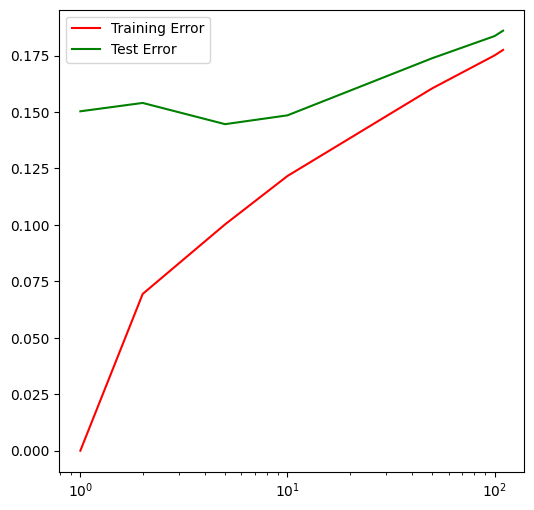

In [6]:
figure, axes = plt.subplots(1, figsize=(6, 6))

k_vals = [1, 2, 5, 10, 50, 100, 110]

tr_error, te_error = compute_knn_errors(X_train, y_train, X_test, y_test, k_vals)
axes.semilogx(k_vals, tr_error, label = "Training Error", color="red" )
axes.semilogx(k_vals, te_error, label = "Test Error", color="green")
axes.legend()


With default parameters, we can see that both training error and testing error are pretty high, with an optiomal number of neightbors for the dataset being around 10, as that is where training and test error are closest around 0.125. Both errors seem to steadily increase from then on. This logic follows intuitively with how kNNs work, as a higher k takes information from data far away from the classification.

### Knowing this, I will now look into different hyperparameters and train only around k = 10.
First, I will also split the data to additionally have validation

In [2]:
fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False)

X = fashion.data
y = fashion.target.astype(int)
X = X / 255.0


c:\Users\trann\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [3]:
X_tv, X_test, y_tv, y_test = train_test_split(
     X, y, test_size = 1/7,  train_size = 6/7, random_state=42, shuffle=True)

X_tv.shape
X_train = X_tv[:50000,:]
y_train = y_tv[:50000]

X_val = X_tv[50000:, :]
y_val = y_tv[50000:]

In [6]:
def test_hyperparameters(X_tr, y_tr, X_te, y_te, k, hyperparam_combinations):
    """Fit a kNN classifier for each k in ks and return train/test error rates.

    X_tr, X_te: feature matrices; shape (n, d).
    y_tr, y_te: label arrays.
    k: number of neighbors
    hyperparameter combination: list of dictionaries of keyword arguments

    Returns:
    all_configs: dictionary of configurations that have the hyperparameters and their train/test error
    """
    ### YOUR CODE STARTS HERE ###

    all_configs = []
    for combination in hyperparam_combinations:
        knn = KNeighborsClassifier(n_neighbors=k, **combination)
        fitted_knn = knn.fit(X_tr, y_tr)

        predicted_train = fitted_knn.predict(X_tr)
        predicted_test = fitted_knn.predict(X_te)

        config_w_errors = combination.copy()
        config_w_errors['train_error'] = (1-accuracy_score(y_tr, predicted_train))
        config_w_errors['test_error'] = (1-accuracy_score(y_te, predicted_test))
        print(config_w_errors)

        all_configs.append(config_w_errors)


    ### YOUR CODE ENDS HERE ###

    return all_configs

In [7]:
weight_options = ["uniform", "distance"]
algorithm_options = ["ball_tree", "brute"]
p_options = [1.0, 2.0]

hp_combs = []
for weight in weight_options:
    for alg in algorithm_options:
        for p in p_options:
            hp_combs.append({"weights": weight,
                             "algorithm": alg,
                              "p": p }
            )

hyperparameter_results = test_hyperparameters(X_train,
                                                         y_train,
                                                          X_test,
                                                         y_test,
                                                         10,
                                                         hp_combs)

{'weights': 'uniform', 'algorithm': 'ball_tree', 'p': 1.0, 'train_error': 0.11960000000000004, 'test_error': 0.14239999999999997}
{'weights': 'uniform', 'algorithm': 'ball_tree', 'p': 2.0, 'train_error': 0.12532, 'test_error': 0.14790000000000003}
{'weights': 'uniform', 'algorithm': 'brute', 'p': 1.0, 'train_error': 0.11960000000000004, 'test_error': 0.14239999999999997}
{'weights': 'uniform', 'algorithm': 'brute', 'p': 2.0, 'train_error': 0.12532, 'test_error': 0.14790000000000003}
{'weights': 'distance', 'algorithm': 'ball_tree', 'p': 1.0, 'train_error': 0.0, 'test_error': 0.1401}
{'weights': 'distance', 'algorithm': 'ball_tree', 'p': 2.0, 'train_error': 0.0, 'test_error': 0.14690000000000003}
{'weights': 'distance', 'algorithm': 'brute', 'p': 1.0, 'train_error': 0.0, 'test_error': 0.1401}
{'weights': 'distance', 'algorithm': 'brute', 'p': 2.0, 'train_error': 0.0, 'test_error': 0.14690000000000003}


In [15]:
hyper_results_dict = {'weights': [],
                                   'algorithm': [],
                                   'p': [],
                                   'train_error': [],
                                   'test_error': []}
for config in hyperparameter_results:
    hyper_results_dict['weights'].append(config["weights"])
    hyper_results_dict['algorithm'].append(config["algorithm"])
    hyper_results_dict['p'].append(config["p"])
    hyper_results_dict['train_error'].append(config["train_error"])
    hyper_results_dict['test_error'].append(config["test_error"])

pd.DataFrame(hyper_results_dict)

,weights,algorithm,p,train_error,test_error
0,uniform,ball_tree,1.0,0.11960,0.1424
1,uniform,ball_tree,2.0,0.12532,0.1479
2,uniform,brute,1.0,0.11960,0.1424
3,uniform,brute,2.0,0.12532,0.1479
4,distance,ball_tree,1.0,0.00000,0.1401
5,distance,ball_tree,2.0,0.00000,0.1469
6,distance,brute,1.0,0.00000,0.1401
7,distance,brute,2.0,0.00000,0.1469


We can see that test error is pretty much the same throughout all configurations, with the smallest ones using distance weights, p=1, and either algorithm. We can see that weights of distance give extremely low training error. However, test_error is overall extremely high.